# Coastline Change

This notebook is based on the work of Geoscience Australia and adopted by Piksel Indonesia. This notebook works in Piksel sandbox.

## Requirements

The algorithm uses two fundameltal datasets, first, optical Earth observation data,
and Landsat is ideal, as it goes back over forty years. And second, is a tidal
model, which is used to annotate scenes with a tide height, and to filter
those scenes to just those in the middle of the tide range, therefore establishing
an 'average' coastline.

## Configuration and setup

First, we import libraries and tools that we need to run the analysis.

In [1]:
import os
from urllib.parse import urlparse

import dask.config
from coastlines.utils import extract_contours, tide_cutoffs
from coastlines.vector import annual_movements, calculate_regressions
from dask.distributed import Client, LocalCluster
from datacube import Datacube
from datacube.utils.masking import create_mask_value, valid_data_mask
from dea_tools.spatial import points_on_line
from eo_tides import pixel_tides
from ipyleaflet import basemaps
from odc.geo.geom import point, BoundingBox
from odc.stac import configure_s3_access
from odc.algo import mask_cleanup
from piksel.utils import patch_usgs_landsat

### Set up our environment

We're going to access Landsat data from USGS using the Element-84 STAC API.

The `configure_s3_access` function will set up the environment for the requester
pays bucket on S3, which USGS shares data from. And we use Dask to lazy-load
data and run the computation in parallel.

In [2]:
# Tide data and config (using absolute path)
tide_data_location = "/home/jovyan/data/coastlines/tide_models"

# Configure AWS
os.environ["AWS_DEFAULT_REGION"] = "us-west-2"

if "AWS_NO_SIGN_REQUEST" in os.environ:
    del os.environ["AWS_NO_SIGN_REQUEST"]

configure_s3_access(requester_pays=True)

# Connect to the Datacube
dc = Datacube(app="coastlines")

Show dashboard URL based on Piksel user

In [3]:
# Set up Dask
cluster = LocalCluster(n_workers=2, threads_per_worker=16, memory_limit="15GB")

dashboard_url = cluster.dashboard_link
port = urlparse(dashboard_url).port

jupyterhub_user = os.environ.get("JUPYTERHUB_USER")
dask.config.set(
    **{"distributed.dashboard.link": f"/user/{jupyterhub_user}/proxy/{port}/status"}
)

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,Workers: 2
Total threads: 32,Total memory: 27.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32777,Workers: 0
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41669,Total threads: 16
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:40187,


### Set up a study location

Configure a spatial location, a time range, and other variables.

In [4]:
variables = {
    "date_range": {
        "landsat": ("1995", "2025"),
        "sentinel": ("2015", "2025"),
    },
    "product": {
        "landsat": ["ls5_c2l2_sr", "ls7_c2l2_sr", "ls8_c2l2_sr", "ls9_c2l2_sr"],
        "sentinel": ["s2_l2a"],
    },
    "resolution": {
        "landsat": 30,
        "sentinel": 10,
    },
    "measurements": {
        "landsat": ["red", "green", "blue", "nir08", "swir16", "qa_pixel"],
        "sentinel": ["red", "green", "blue", "nir08", "swir16", "swir22", "scl"],
    },
    "resampling": {
        "landsat" : {"*": "cubic", "qa_pixel": "nearest"},
        "sentinel": {"*": "cubic", "scl": "nearest"},
    },
    "max_cloud_cover": 90,  # Maximum cloud cover percentage
    "output_crs": "EPSG:6933",  # try 4326 or 6933
    "dask_chunk": {"time": 1, "x": 520, "y": 520},
    "locaiton_name": "sagulubbe",
}

# Find a location you're interested in on Google Maps and copy the coordinates
# by right-clicking on the map and clicking the coordinates

# Insert coordinates of the opposing corners on the area of interest
lat1, lon1 = -1.64971772, 98.86185490
lat2, lon2 = -1.66981624, 98.87291348

# switch lat and long so that 1 is always less than 2
if lat1 > lat2:
    lat1, lat2 = lat2, lat1
if lon1 > lon2:
    lon1, lon2 = lon2, lon1

area = BoundingBox(lon1, lat1, lon2, lat2)

# # Insert coordinates in the middle of the area of interest
# coords = -2.8529196362943305, 110.59169231646739

# aoi_point = point(coords[1], coords[0], crs="EPSG:4326")
# area = aoi_point.buffer(0.03).boundingbox

area.explore(tiles=basemaps.Esri.WorldImagery)

### Find and load data

Search for Landsat scenes and load them into memory using Dask.

In [5]:
categories_to_mask_landsat = {
    "cloud": "high_confidence",
    "cloud_shadow": "high_confidence",
}

# Find and load Landsat datasets
landsat_datasets = dc.find_datasets(
    product=variables["product"]["landsat"],
    time=variables["date_range"]["landsat"],
    longitude=(area.left, area.right),
    latitude=(area.bottom, area.top),
    cloud_cover=(0, variables["max_cloud_cover"]),
    collection_category="T1",  # Only include T1 quality data
)

print(f"Found {len(landsat_datasets)} Landsat datasets")

landsat_data = dc.load(
    datasets=landsat_datasets,
    longitude=(area.left, area.right),
    latitude=(area.bottom, area.top),
    resolution=variables["resolution"]["landsat"],
    output_crs=variables["output_crs"],
    measurements=variables["measurements"]["landsat"],
    group_by="solar_day",
    dask_chunks=variables["dask_chunk"],
    resampling=variables["resampling"]["landsat"],
    patch_url=patch_usgs_landsat,
    driver="rio",
)

Found 567 Landsat datasets


Search for Sentinel-2 scenes

In [6]:
sentinel_datasets = dc.find_datasets(
    product=variables["product"]["sentinel"],
    time=variables["date_range"]["sentinel"],
    longitude=(area.left, area.right),
    latitude=(area.bottom, area.top),
    cloud_cover=(0, variables["max_cloud_cover"]),
)

print(f"Found {len(sentinel_datasets)} Sentinel-2 datasets")

sentinel_data = dc.load(
    datasets=sentinel_datasets,
    longitude=(area.left, area.right),
    latitude=(area.bottom, area.top),
    resolution=variables["resolution"]["sentinel"],
    output_crs=variables["output_crs"],
    measurements=variables["measurements"]["sentinel"],
    group_by="solar_day",
    dask_chunks=variables["dask_chunk"],
    resampling=variables["resampling"]["sentinel"],
    driver="rio",
)

Found 491 Sentinel-2 datasets


### Preview data

This cell first selects the first four scenes using the `isel` or "index select" function.
And then plots that from an array, so that we get an RGB visualisation.

/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


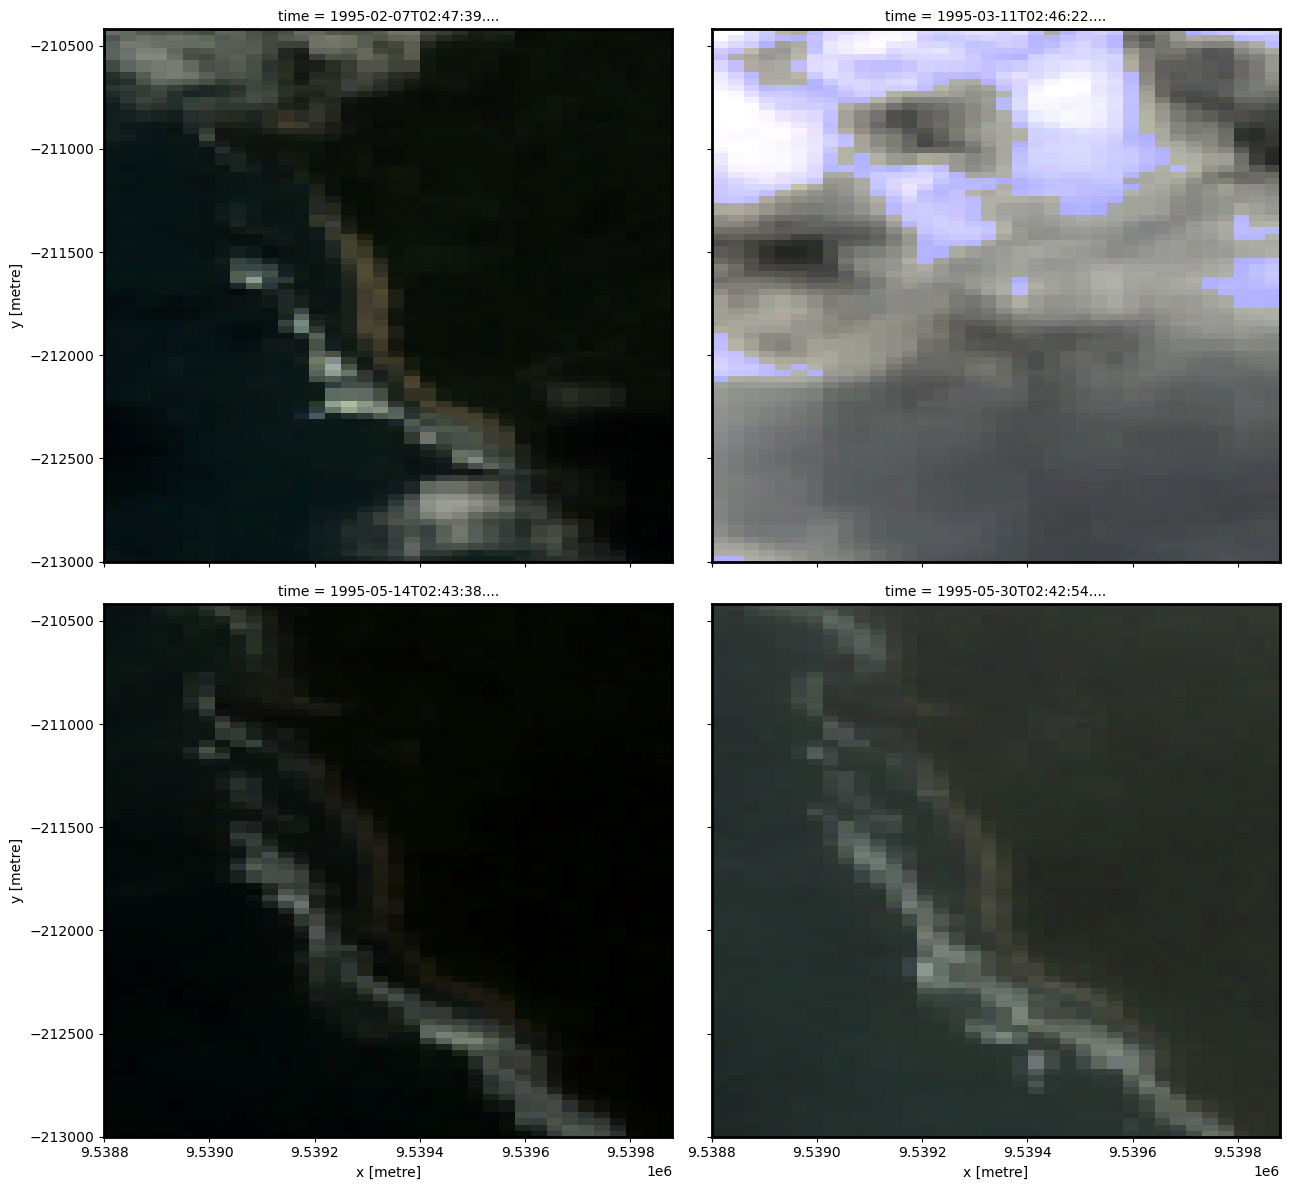

In [7]:
ls_data_subset = landsat_data[["red", "green", "blue"]].isel(time=slice(0, 4))
ls_data_subset.to_array().plot.imshow(col="time", col_wrap=2, size=6, robust=True)

/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


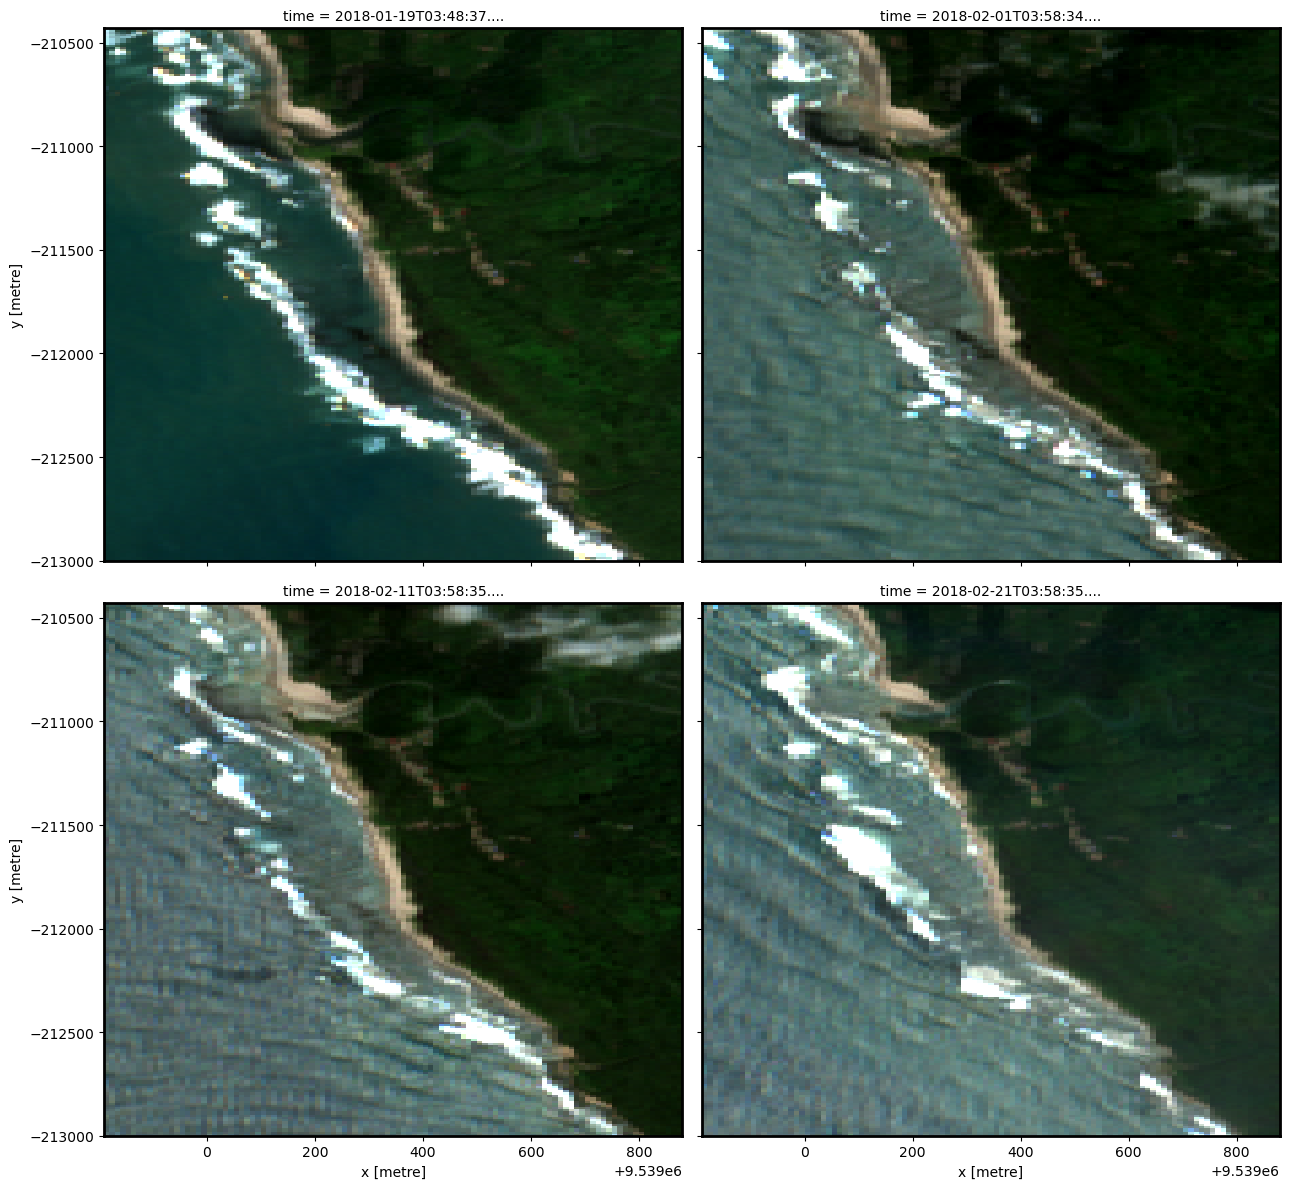

In [ ]:
sentinel_data_subset = sentinel_data[["red", "green", "blue"]].isel(time=slice(0, 4))
sentinel_data_subset.to_array().plot.imshow(col="time", col_wrap=2, size=6, robust=True)

## Data processing

### Cloud masking

Now we know we have some good data, we can start processing. First we need to mask
out clouds, so that they don't impact our results.

In [9]:
# Mask Landsat data
ls_mask_value, _ = create_mask_value(
    landsat_datasets[0].product.measurements["qa_pixel"].flags_definition,
    **categories_to_mask_landsat,
)

ls_cloud_mask = (landsat_data.qa_pixel & ls_mask_value) != 0
ls_valid_data = valid_data_mask(landsat_data)
landsat_mask = ls_cloud_mask | ~ls_valid_data

ls_cloud_masked = landsat_data.where(~landsat_mask).drop_vars("qa_pixel")

# Scale Landsat data, so that values are between 0 and 1
ls_cloud_masked = (ls_cloud_masked * 0.0000275 - 0.2).clip(0, 1)

ls_cloud_masked

<xarray.Dataset> Size: 35MB
Dimensions:      (time: 561, y: 86, x: 36)
Coordinates:
  * y            (y) float64 688B -2.104e+05 -2.105e+05 ... -2.13e+05 -2.13e+05
  * x            (x) float64 288B 9.539e+06 9.539e+06 ... 9.54e+06 9.54e+06
    spatial_ref  int32 4B 6933
  * time         (time) datetime64[ns] 4kB 1995-02-07T02:47:39.651019 ... 202...
Data variables:
    red          (time, y, x) float32 7MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    green        (time, y, x) float32 7MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    blue         (time, y, x) float32 7MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    nir08        (time, y, x) float32 7MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    swir16       (time, y, x) float32 7MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>

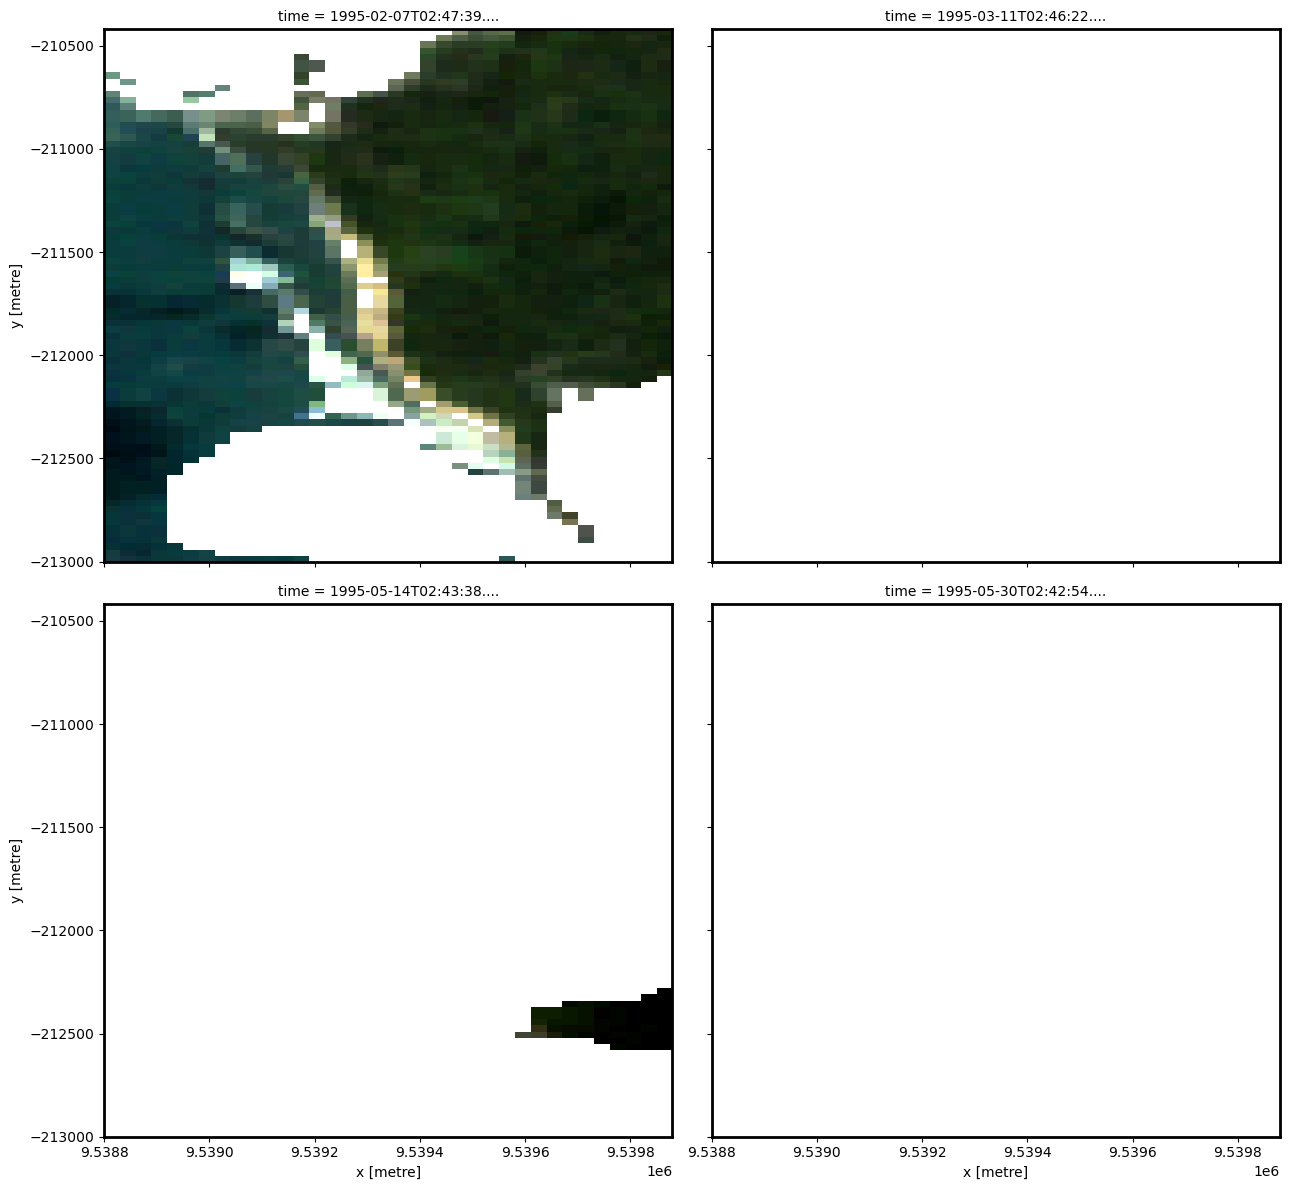

In [10]:
# Preview the masked data
ls_masked_subset = ls_cloud_masked[["red", "green", "blue"]].isel(time=range(0, 4))
ls_masked_subset.to_array().plot.imshow(col="time", col_wrap=2, size=6, robust=True)

Mask Sentinel

In [11]:
# Mask Sentinel-2 data
# 3 is cloud shadow, 8 is medium probability cloud, 9 is high probability cloud
s_cloud_mask = sentinel_data.scl.isin([3, 8, 9])
s_cloud_mask = mask_cleanup(s_cloud_mask, (("dilation", 10), ("erosion", 5)))
s_valid_data = valid_data_mask(sentinel_data)
sentinel_mask= s_cloud_mask | ~s_valid_data

s_cloud_masked = sentinel_data.where(~sentinel_mask).drop_vars("scl")

# Scale Sentinel-2 data so that values are between 0 and 1
s_cloud_masked = (s_cloud_masked * 0.0001).clip(0, 1)  # Scale Sentinel-2 data to match Landsat scale

### Tide masking

This cell filters out scenes that are wholy in the "extreme" tides, or those
outside the middle 50% of observations.

In [12]:
# Add tide height to the data
landsat_tides = pixel_tides(
    ls_cloud_masked,
    resample=True,
    directory=tide_data_location,
    model="INATIDES",
    dask_compute=True,
)

# Determine tide cutoff
ls_tide_cutoff_min, ls_tide_cutoff_max = tide_cutoffs(landsat_data, landsat_tides, tide_centre=0.0)

ls_tide_bool = (landsat_tides >= ls_tide_cutoff_min) & (landsat_tides <= ls_tide_cutoff_max)
ls_data_filtered = ls_cloud_masked.sel(time=ls_tide_bool.sum(dim=["x", "y"]) > 0)

# Apply mask, and load in corresponding tide masked data
ls_data_tide_masked = ls_data_filtered.where(ls_tide_bool)
ls_data_tide_masked

Creating reduced resolution 5000 x 5000 metre tide modelling array
Modelling tides with INATIDES
Reprojecting tides into original resolution


<xarray.Dataset> Size: 24MB
Dimensions:      (time: 393, y: 86, x: 36)
Coordinates:
  * y            (y) float64 688B -2.104e+05 -2.105e+05 ... -2.13e+05 -2.13e+05
  * x            (x) float64 288B 9.539e+06 9.539e+06 ... 9.54e+06 9.54e+06
  * time         (time) datetime64[ns] 3kB 1995-02-07T02:47:39.651019 ... 202...
    spatial_ref  int32 4B 6933
    tide_model   <U8 32B 'INATIDES'
Data variables:
    red          (time, y, x) float32 5MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    green        (time, y, x) float32 5MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    blue         (time, y, x) float32 5MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    nir08        (time, y, x) float32 5MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>
    swir16       (time, y, x) float32 5MB dask.array<chunksize=(1, 86, 36), meta=np.ndarray>

In [13]:
sentinel_tides = pixel_tides(
    s_cloud_masked,
    resample=True,
    directory=tide_data_location,
    model="INATIDES",
    dask_compute=True,
)

# Determine tide cutoff
s_tide_cutoff_min, s_tide_cutoff_max = tide_cutoffs(sentinel_data, sentinel_tides, tide_centre=0.0)

s_tide_bool = (sentinel_tides >= s_tide_cutoff_min) & (sentinel_tides <= s_tide_cutoff_max)
s_data_filtered = s_cloud_masked.sel(time=s_tide_bool.sum(dim=["x", "y"]) > 0)

# Apply mask, and load in corresponding tide masked data
s_data_tide_masked = s_data_filtered.where(s_tide_bool)
s_data_tide_masked

Creating reduced resolution 5000 x 5000 metre tide modelling array
Modelling tides with INATIDES
Reprojecting tides into original resolution


<xarray.Dataset> Size: 206MB
Dimensions:      (time: 312, y: 257, x: 107)
Coordinates:
  * y            (y) float64 2kB -2.104e+05 -2.104e+05 ... -2.13e+05 -2.13e+05
  * x            (x) float64 856B 9.539e+06 9.539e+06 ... 9.54e+06 9.54e+06
  * time         (time) datetime64[ns] 2kB 2018-01-19T03:48:37.584000 ... 202...
    spatial_ref  int32 4B 6933
    tide_model   <U8 32B 'INATIDES'
Data variables:
    red          (time, y, x) float32 34MB dask.array<chunksize=(1, 257, 107), meta=np.ndarray>
    green        (time, y, x) float32 34MB dask.array<chunksize=(1, 257, 107), meta=np.ndarray>
    blue         (time, y, x) float32 34MB dask.array<chunksize=(1, 257, 107), meta=np.ndarray>
    nir08        (time, y, x) float32 34MB dask.array<chunksize=(1, 257, 107), meta=np.ndarray>
    swir16       (time, y, x) float32 34MB dask.array<chunksize=(1, 257, 107), meta=np.ndarray>
    swir22       (time, y, x) float32 34MB dask.array<chunksize=(1, 257, 107), meta=np.ndarray>

### Identify land and water

We use a water index, here it's a combination of the normalised difference wetness index, NDWI,
and the modified version of that, MNDWI. We find the average of the two indices, which has been
found to be more robust to issues of noisy data over ocean in Landsat.

In [ ]:
index_names = ["combined", "scowi", "mndwi_nir",]

In [14]:
def mndwi(green, swir1):
    """
    Calculate the Modified Normalized Difference Water Index (MNDWI).
    """

    return (green - swir1) / (green + swir1)

def ndwi(green, nir):
    """
    Calculate the Normalized Difference Water Index (NDWI).
    """

    return (green - nir) / (green + nir)

def scowi(blue, green, nir, swir1):
    """
    Calculate the Sentinel Combined Ocean Water Index (SCOWI).
    """

    return blue + 2 * (green - nir) - 0.75 * swir1 - 0.5 * swir1

def mndwi_nir(green, nir, swir1):
    """
    Calculate the Modified Normalized Difference Water Index (MNDWI) using NIR.
    """

    scaled_green = green + (nir.max(dim="time") - nir) / 2
    scaled_swir1 = (swir1 + nir) / 2

    return (scaled_green - scaled_swir1) / (scaled_green + scaled_swir1)

In [15]:
# Create Combined index (the mean of MNDWI and NDWI)
index_name = "combined"
ls_data_tide_masked[index_name] = (
    mndwi(
        green=ls_data_tide_masked.green, 
        swir1=ls_data_tide_masked.swir16,
    ) + ndwi(
        green=ls_data_tide_masked.green, 
        nir=ls_data_tide_masked.nir08,
    ) / 2
)

s_data_tide_masked[index_name] = (
    mndwi(
        green=s_data_tide_masked.green, 
        swir1=s_data_tide_masked.swir16,
    ) + ndwi(
        green=s_data_tide_masked.green, 
        nir=s_data_tide_masked.nir08,
    ) / 2
)

In [ ]:
# # Create SCOWI index, which is an alternative to the above combined index
# index_name = "scowi"
# ls_data_tide_masked[index_name] = scowi(
#     blue=ls_data_tide_masked.blue,
#     green=ls_data_tide_masked.green,
#     nir=ls_data_tide_masked.nir08,
#     swir1=ls_data_tide_masked.swir16,
# )

In [ ]:
# # Create MNDWI_NIR index
# index_name = "mndwi_nir"
# ls_data_tide_masked[index_name] = mndwi_nir(
#     green=ls_data_tide_masked.green,
#     nir=ls_data_tide_masked.nir08,
#     swir1=ls_data_tide_masked.swir16,
# )

In [16]:
landsat_yearly = (
    ls_data_tide_masked[index_name]
    .groupby("time.year")
    .median()
    .to_dataset(name=index_name)
)
landsat_yearly = landsat_yearly.compute()

In [17]:
sentinel_yearly = (
    s_data_tide_masked[index_name]
    .groupby("time.year")
    .median()
    .to_dataset(name=index_name)
)
sentinel_yearly = sentinel_yearly.compute()

### Extract contours

Next we extract contour lines from the underlying land/water raster data.

In [18]:
# You can also try using the other index above
# use z_value of 0.0 for 'mndwi'
# use z_value of 0.65 for `mndwi_nir`
z_values = 0.0

ls_contour_gdf = extract_contours(
    landsat_yearly, z_values=z_values, index_name=index_name
)

ls_contour_gdf.reset_index().explore(
    column="year",
    cmap="magma",
    style_kwds={"weight": 3},
    tiles=basemaps.Esri.WorldImagery,
)

In [19]:
s_contour_gdf = extract_contours(
    sentinel_yearly, z_values=z_values, index_name=index_name
)

s_contour_gdf.reset_index().explore(
    column="year",
    cmap="magma",
    style_kwds={"weight": 3},
    tiles=basemaps.Esri.WorldImagery,
)

### Extract points

And from the contours, we extract points, and annotate them with change over time, so that
we can document how much the coastline has eroded or accreted.

In [21]:
# Extract points at every 30 metres along the most recent shoreline
ls_points_gdf = points_on_line(ls_contour_gdf, index=2023, distance=30)

# Calculate annual movements based on the points from above
ls_points_gdf = annual_movements(
    ls_points_gdf,
    contours_gdf=ls_contour_gdf,
    yearly_ds=landsat_yearly,
    baseline_year=2023,
    water_index=index_name,
)

# And regression lines
ls_points_gdf = calculate_regressions(points_gdf=ls_points_gdf)

In [22]:
# Extract points at every 30 metres along the most recent shoreline
s_points_gdf = points_on_line(s_contour_gdf, index=2023, distance=30)

# Calculate annual movements based on the points from above
s_points_gdf = annual_movements(
    s_points_gdf,
    contours_gdf=s_contour_gdf,
    yearly_ds=landsat_yearly,
    baseline_year=2023,
    water_index=index_name,
)

# And regression lines
s_points_gdf = calculate_regressions(points_gdf=s_points_gdf)

## Visualisation

Finally, visualise the results together.

In [23]:
# Add human-friendly label for plotting
ls_points_gdf["Coastal change"] = ls_points_gdf.apply(
    lambda x: f"<h4>This coastline has {'<b>retreated</b>' if x.rate_time < 0 else '<b>grown</b>'} "
    f"by</br><b>{x.rate_time:.2f} m (±{x.se_time:.1f}) per year</b> since "
    f"<b>{ls_contour_gdf.index[0]}</b></h4>",
    axis=1,
)
ls_points_gdf.loc[ls_points_gdf.sig_time > 0.05, "Coastal change"] = (
    f"<h4>No significant trend of retreat or growth)</h4>"
)

m = ls_contour_gdf.reset_index().explore(
    column="year",
    cmap="inferno",
    tooltip=False,
    style_kwds={"opacity": 0.5},
    categorical=True,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="ESRI WorldImagery",
)

ls_points_gdf.explore(
    m=m,
    column="rate_time",
    cmap="RdBu",
    markersize=5,
    tooltip="Coastal change",
)

In [24]:
# Add human-friendly label for plotting
s_points_gdf["Coastal change"] = s_points_gdf.apply(
    lambda x: f"<h4>This coastline has {'<b>retreated</b>' if x.rate_time < 0 else '<b>grown</b>'} "
    f"by</br><b>{x.rate_time:.2f} m (±{x.se_time:.1f}) per year</b> since "
    f"<b>{s_contour_gdf.index[0]}</b></h4>",
    axis=1,
)
s_points_gdf.loc[s_points_gdf.sig_time > 0.05, "Coastal change"] = (
    f"<h4>No significant trend of retreat or growth)</h4>"
)

m = s_contour_gdf.reset_index().explore(
    column="year",
    cmap="inferno",
    tooltip=False,
    style_kwds={"opacity": 0.5},
    categorical=True,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="ESRI WorldImagery",
)

s_points_gdf.explore(
    m=m,
    column="rate_time",
    cmap="RdBu",
    markersize=5,
    tooltip="Coastal change",
)

In [ ]:
# # Export results to GeoPackage

# ls_points_gdf.to_file(f"ls_{variable["location_name"]}_rate_of_change.gpkg", layer="rate_of_change", driver="GPKG")
# ls_contour_gdf.to_file(f"ls_{variable["location_name"]}_shorelines.gpkg", layer="shorelines", driver="GPKG")